In [1]:
from google.colab import userdata
import os

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

In [2]:
!pip install kaggle -q

import os
os.makedirs('/content/cassava', exist_ok=True)

!kaggle competitions download -c cassava-leaf-disease-classification -p /content/cassava

100% 5.76G/5.76G [00:36<00:00, 172MB/s]



In [3]:
import zipfile

with zipfile.ZipFile('/content/cassava/cassava-leaf-disease-classification.zip', 'r') as z:
    z.extractall('/content/cassava')

print("Done extracting")
!ls /content/cassava

Done extracting
cassava-leaf-disease-classification.zip  test_images	 train_images
label_num_to_disease_map.json		 test_tfrecords  train_tfrecords
sample_submission.csv			 train.csv


In [4]:
import os
import json
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
GPU available: True
Device: Tesla T4


In [5]:
BASE_DIR = '/content/cassava'
IMG_DIR = os.path.join(BASE_DIR, 'train_images')

df = pd.read_csv(os.path.join(BASE_DIR, 'train.csv'))

with open(os.path.join(BASE_DIR, 'label_num_to_disease_map.json')) as f:
    label_map = json.load(f)

print(f"Total samples: {len(df)}")
print(f"Class distribution:\n{df['label'].value_counts().sort_index()}")
print(f"\nLabel map: {label_map}")

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"\nTrain size: {len(train_df)}")
print(f"Val size: {len(val_df)}")
print(f"\nTrain class distribution:\n{train_df['label'].value_counts().sort_index()}")
print(f"\nVal class distribution:\n{val_df['label'].value_counts().sort_index()}")

Total samples: 21397
Class distribution:
label
0     1087
1     2189
2     2386
3    13158
4     2577
Name: count, dtype: int64

Label map: {'0': 'Cassava Bacterial Blight (CBB)', '1': 'Cassava Brown Streak Disease (CBSD)', '2': 'Cassava Green Mottle (CGM)', '3': 'Cassava Mosaic Disease (CMD)', '4': 'Healthy'}

Train size: 17117
Val size: 4280

Train class distribution:
label
0      870
1     1751
2     1909
3    10526
4     2061
Name: count, dtype: int64

Val class distribution:
label
0     217
1     438
2     477
3    2632
4     516
Name: count, dtype: int64


In [6]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


class CassavaDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.df['image_id'][idx])
        image = Image.open(img_path).convert('RGB')
        label = self.df['label'][idx]
        if self.transform:
            image = self.transform(image)
        return image, label

train_dataset = CassavaDataset(train_df, IMG_DIR, transform=train_transforms)
val_dataset = CassavaDataset(val_df, IMG_DIR, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train batches: 535
Val batches: 134


In [7]:
images, labels = next(iter(train_loader))

print(f"Image batch shape: {images.shape}")
print(f"Labels batch shape: {labels.shape}")
print(f"Label values in batch: {labels.unique()}")
print(f"Image dtype: {images.dtype}")
print(f"Min pixel val: {images.min():.3f}, Max pixel val: {images.max():.3f}")

Image batch shape: torch.Size([32, 3, 224, 224])
Labels batch shape: torch.Size([32])
Label values in batch: tensor([0, 1, 2, 3, 4])
Image dtype: torch.float32
Min pixel val: -2.118, Max pixel val: 2.640


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class CassavaCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(CassavaCNN, self).__init__()

       
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)

        self.fc1 = nn.Linear(256 * 14 * 14, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))

        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CassavaCNN(num_classes=5).to(device)


dummy = torch.randn(2, 3, 224, 224).to(device)
out = model(dummy)
print(f"Output shape: {out.shape}")  # expect [2, 5]
print(f"Model on: {device}")

Output shape: torch.Size([2, 5])
Model on: cuda


In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

print("Loss: CrossEntropyLoss")
print("Optimizer: Adam, lr=1e-3")
print("Scheduler: StepLR, halve lr every 5 epochs")

Loss: CrossEntropyLoss
Optimizer: Adam, lr=1e-3
Scheduler: StepLR, halve lr every 5 epochs


In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=10):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

       
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        
        train_loss_avg = train_loss / len(train_loader)
        val_loss_avg = val_loss / len(val_loader)
        train_acc = 100 * train_correct / train_total
        val_acc = 100 * val_correct / val_total

        history['train_loss'].append(train_loss_avg)
        history['val_loss'].append(val_loss_avg)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        scheduler.step()

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss_avg:.4f} Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss_avg:.4f} Acc: {val_acc:.2f}%")

    return history

history = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=10)












Epoch [1/10] Train Loss: 1.9151 Acc: 59.41% | Val Loss: 1.0297 Acc: 61.50%
Epoch [2/10] Train Loss: 1.0874 Acc: 61.75% | Val Loss: 1.0088 Acc: 61.54%
Epoch [3/10] Train Loss: 1.0513 Acc: 62.38% | Val Loss: 0.9778 Acc: 62.41%
Epoch [4/10] Train Loss: 1.0295 Acc: 62.71% | Val Loss: 0.9549 Acc: 65.75%
Epoch [5/10] Train Loss: 1.0237 Acc: 63.14% | Val Loss: 0.9282 Acc: 64.88%
Epoch [6/10] Train Loss: 0.9786 Acc: 63.62% | Val Loss: 0.9005 Acc: 65.51%
Epoch [7/10] Train Loss: 0.9762 Acc: 63.55% | Val Loss: 1.1784 Acc: 63.53%
Epoch [8/10] Train Loss: 0.9712 Acc: 63.73% | Val Loss: 0.8757 Acc: 65.47%
Epoch [9/10] Train Loss: 0.9586 Acc: 64.05% | Val Loss: 0.8757 Acc: 66.66%
Epoch [10/10] Train Loss: 0.9605 Acc: 64.05% | Val Loss: 1.0940 Acc: 64.02%


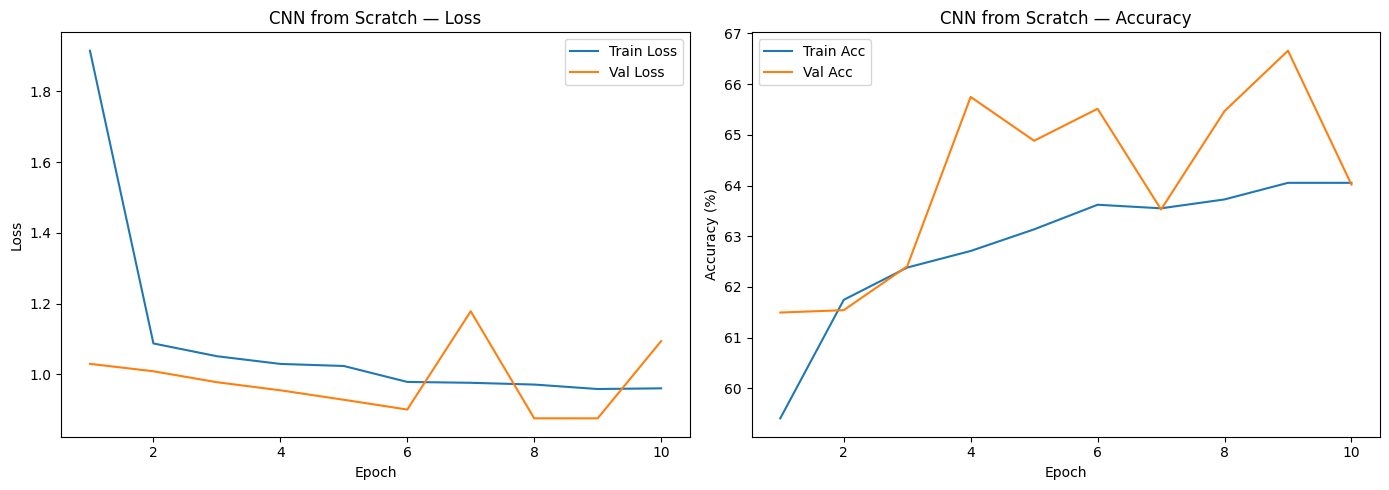

Saved.


In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, 11)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, history['train_loss'], label='Train Loss')
ax1.plot(epochs_range, history['val_loss'], label='Val Loss')
ax1.set_title('CNN from Scratch — Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs_range, history['train_acc'], label='Train Acc')
ax2.plot(epochs_range, history['val_acc'], label='Val Acc')
ax2.set_title('CNN from Scratch — Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()

plt.tight_layout()
plt.savefig('scratch_cnn_curves.png', dpi=150)
plt.show()
print("Saved.")

In [ ]:
import torchvision.models as models

def get_efficientnet(num_classes=5):
    model = models.efficientnet_b0(weights='IMAGENET1K_V1')

    
    for param in model.parameters():
        param.requires_grad = False

    
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, num_classes)
    )

    return model

transfer_model = get_efficientnet(num_classes=5).to(device)


dummy = torch.randn(2, 3, 224, 224).to(device)
out = transfer_model(dummy)
print(f"Output shape: {out.shape}")

trainable = sum(p.numel() for p in transfer_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in transfer_model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 151MB/s]


Output shape: torch.Size([2, 5])
Trainable params: 6,405 / 4,013,953


In [ ]:
transfer_optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, transfer_model.parameters()),
    lr=1e-3
)
transfer_scheduler = optim.lr_scheduler.StepLR(transfer_optimizer, step_size=5, gamma=0.5)

print("Transfer model training setup done")
print("Only classifier head weights will be updated")


Transfer model training setup done
Only classifier head weights will be updated


In [ ]:
transfer_history = train_model(
    transfer_model,
    train_loader,
    val_loader,
    criterion,
    transfer_optimizer,
    transfer_scheduler,
    epochs=10
)

Epoch [1/10] Train Loss: 0.9260 Acc: 66.89% | Val Loss: 0.8782 Acc: 68.22%
Epoch [2/10] Train Loss: 0.8573 Acc: 68.90% | Val Loss: 0.8283 Acc: 69.93%
Epoch [3/10] Train Loss: 0.8411 Acc: 69.23% | Val Loss: 0.8319 Acc: 69.93%
Epoch [4/10] Train Loss: 0.8284 Acc: 69.99% | Val Loss: 0.8320 Acc: 69.93%
Epoch [5/10] Train Loss: 0.8270 Acc: 69.88% | Val Loss: 0.8098 Acc: 70.93%
Epoch [6/10] Train Loss: 0.8122 Acc: 70.36% | Val Loss: 0.8221 Acc: 70.30%
Epoch [7/10] Train Loss: 0.8233 Acc: 70.08% | Val Loss: 0.8128 Acc: 70.49%
Epoch [8/10] Train Loss: 0.8092 Acc: 70.37% | Val Loss: 0.8428 Acc: 69.51%
Epoch [9/10] Train Loss: 0.8111 Acc: 70.17% | Val Loss: 0.7920 Acc: 71.52%
Epoch [10/10] Train Loss: 0.8102 Acc: 70.32% | Val Loss: 0.8035 Acc: 71.00%


In [ ]:

for param in transfer_model.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in transfer_model.parameters() if p.requires_grad)
print(f"Trainable params now: {trainable:,}")

finetune_optimizer = optim.Adam(transfer_model.parameters(), lr=1e-4)
finetune_scheduler = optim.lr_scheduler.StepLR(finetune_optimizer, step_size=5, gamma=0.5)

finetune_history = train_model(
    transfer_model,
    train_loader,
    val_loader,
    criterion,
    finetune_optimizer,
    finetune_scheduler,
    epochs=10
)


Trainable params now: 4,013,953
Epoch [1/10] Train Loss: 0.6613 Acc: 76.43% | Val Loss: 0.5467 Acc: 81.40%
Epoch [2/10] Train Loss: 0.5236 Acc: 81.16% | Val Loss: 0.5018 Acc: 82.83%
Epoch [3/10] Train Loss: 0.4606 Acc: 83.57% | Val Loss: 0.4737 Acc: 83.90%
Epoch [4/10] Train Loss: 0.4259 Acc: 84.87% | Val Loss: 0.4706 Acc: 84.32%
Epoch [5/10] Train Loss: 0.3893 Acc: 86.17% | Val Loss: 0.4514 Acc: 84.86%
Epoch [6/10] Train Loss: 0.3485 Acc: 87.70% | Val Loss: 0.4495 Acc: 85.14%
Epoch [7/10] Train Loss: 0.3284 Acc: 87.97% | Val Loss: 0.4516 Acc: 84.93%
Epoch [8/10] Train Loss: 0.3075 Acc: 88.89% | Val Loss: 0.4651 Acc: 85.02%
Epoch [9/10] Train Loss: 0.2952 Acc: 89.53% | Val Loss: 0.4686 Acc: 85.16%
Epoch [10/10] Train Loss: 0.2710 Acc: 90.27% | Val Loss: 0.4663 Acc: 85.23%


In [ ]:

torch.save(transfer_model.state_dict(), '/content/efficientnet_finetuned.pth')
print("Model saved")

Model saved


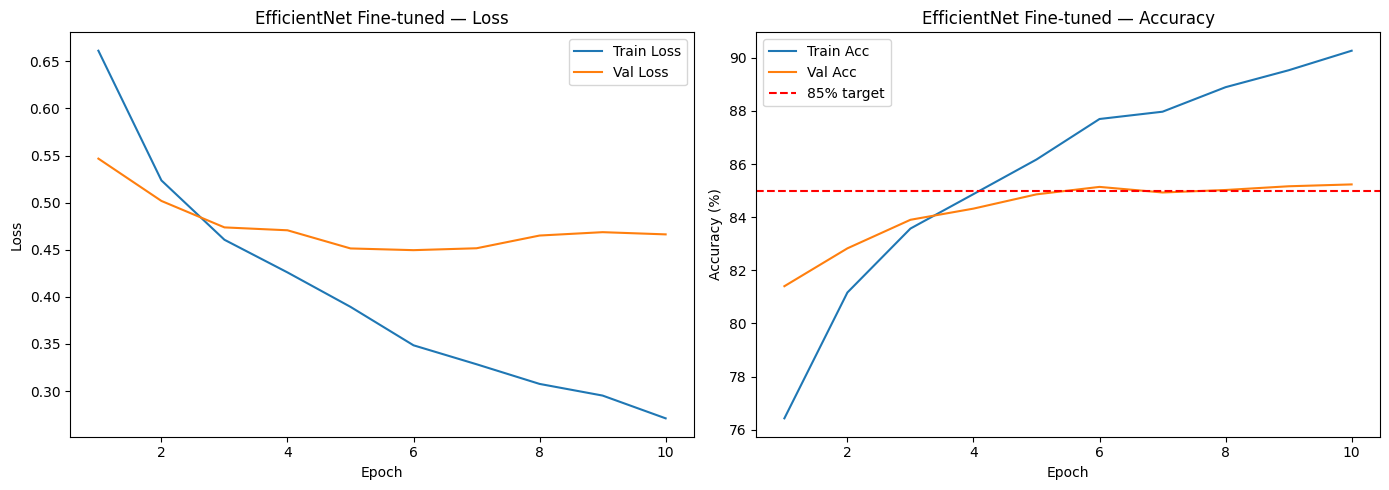

Saved.


In [ ]:

epochs_range = range(1, 11)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, finetune_history['train_loss'], label='Train Loss')
ax1.plot(epochs_range, finetune_history['val_loss'], label='Val Loss')
ax1.set_title('EfficientNet Fine-tuned — Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs_range, finetune_history['train_acc'], label='Train Acc')
ax2.plot(epochs_range, finetune_history['val_acc'], label='Val Acc')
ax2.axhline(y=85, color='r', linestyle='--', label='85% target')
ax2.set_title('EfficientNet Fine-tuned — Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()

plt.tight_layout()
plt.savefig('efficientnet_curves.png', dpi=150)
plt.show()
print("Saved.")

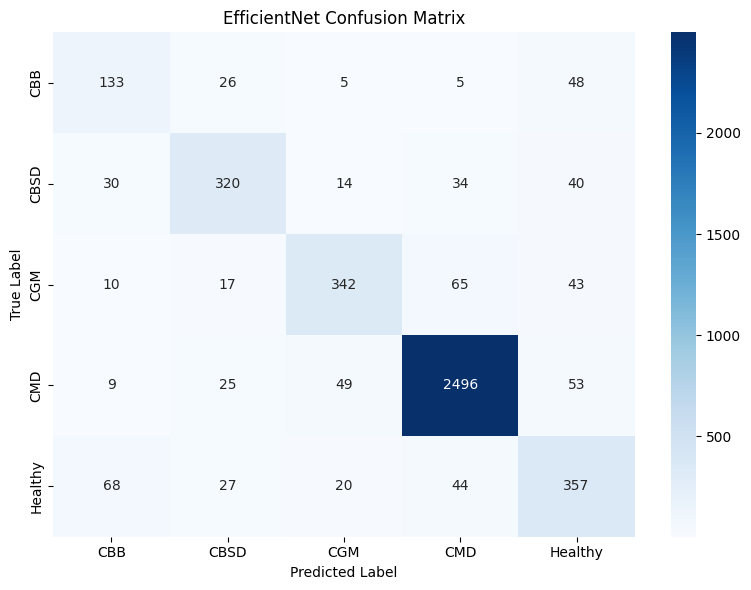


Classification Report:
              precision    recall  f1-score   support

         CBB       0.53      0.61      0.57       217
        CBSD       0.77      0.73      0.75       438
         CGM       0.80      0.72      0.75       477
         CMD       0.94      0.95      0.95      2632
     Healthy       0.66      0.69      0.68       516

    accuracy                           0.85      4280
   macro avg       0.74      0.74      0.74      4280
weighted avg       0.85      0.85      0.85      4280



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


transfer_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = transfer_model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())


class_names = ['CBB', 'CBSD', 'CGM', 'CMD', 'Healthy']


cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('EfficientNet Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()


print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

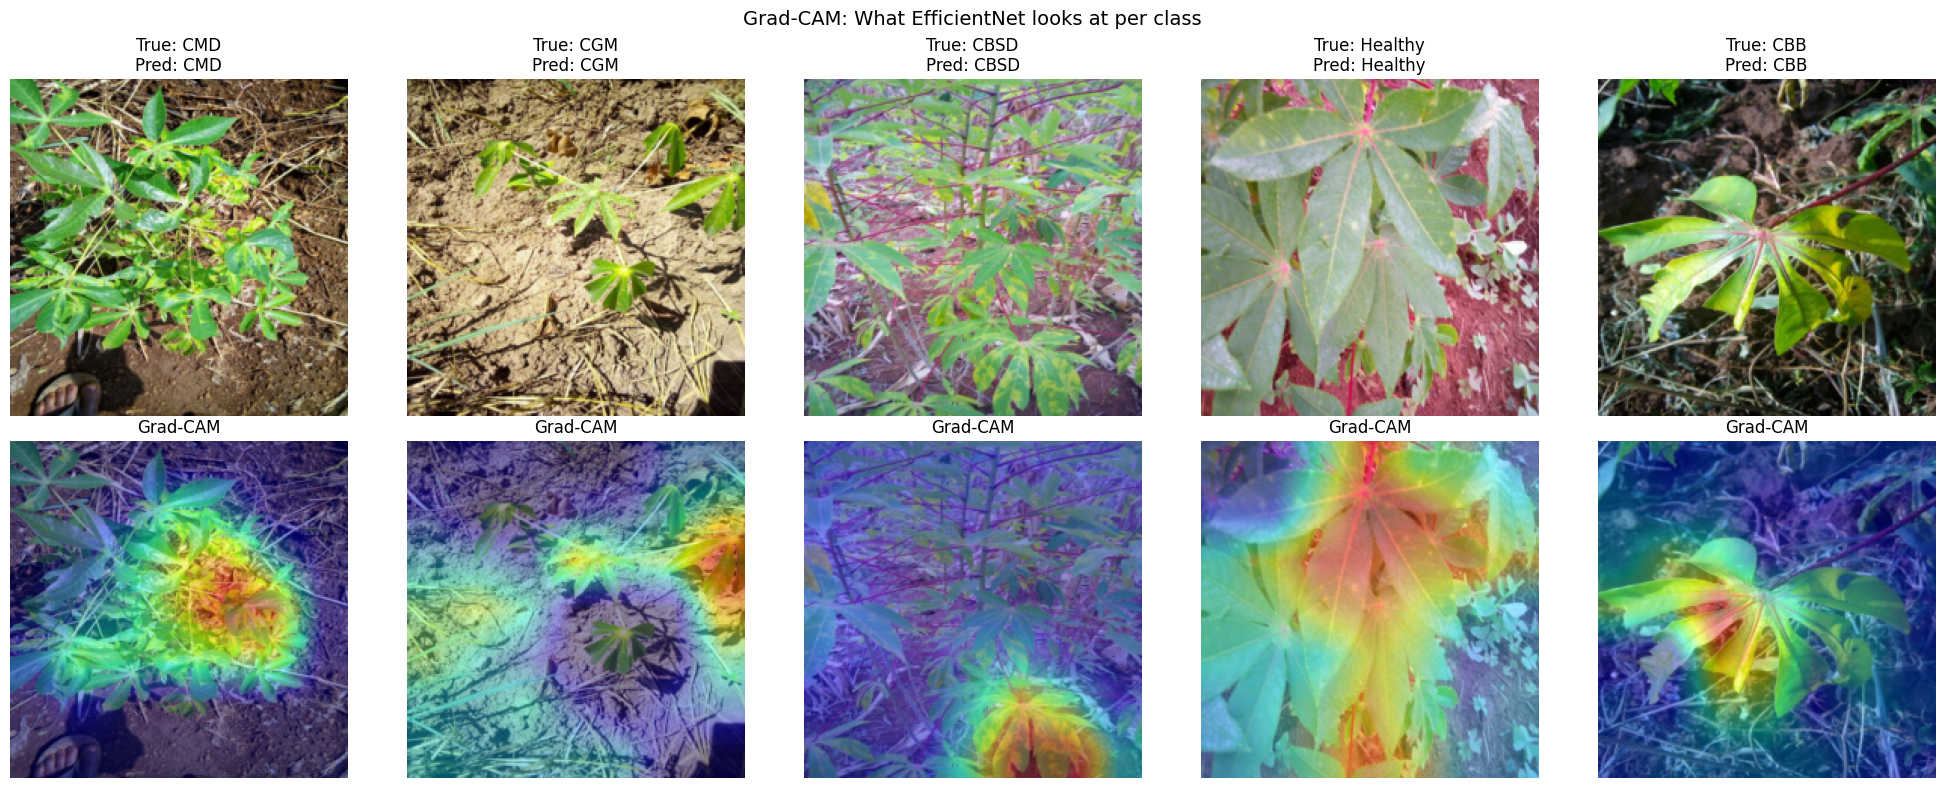

Saved.


In [ ]:
import cv2
import numpy as np


class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, class_idx].backward()

        
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx

target_layer = transfer_model.features[-1]
gradcam = GradCAM(transfer_model, target_layer)


class_names = ['CBB', 'CBSD', 'CGM', 'CMD', 'Healthy']
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

seen_classes = set()
samples = []

for images, labels in val_loader:
    for img, label in zip(images, labels):
        if label.item() not in seen_classes:
            samples.append((img, label.item()))
            seen_classes.add(label.item())
        if len(seen_classes) == 5:
            break
    if len(seen_classes) == 5:
        break

for idx, (img_tensor, label) in enumerate(samples):
    input_tensor = img_tensor.unsqueeze(0).to(device)
    cam, pred_class = gradcam.generate(input_tensor)

   
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])
    img_display = img_tensor.cpu() * std[:, None, None] + mean[:, None, None]
    img_display = img_display.permute(1, 2, 0).numpy()
    img_display = np.clip(img_display, 0, 1)

    
    cam_resized = cv2.resize(cam, (224, 224))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    overlay = 0.6 * img_display + 0.4 * heatmap
    overlay = np.clip(overlay, 0, 1)

    axes[0, idx].imshow(img_display)
    axes[0, idx].set_title(f'True: {class_names[label]}\nPred: {class_names[pred_class]}')
    axes[0, idx].axis('off')

    axes[1, idx].imshow(overlay)
    axes[1, idx].set_title('Grad-CAM')
    axes[1, idx].axis('off')

plt.suptitle('Grad-CAM: What EfficientNet looks at per class', fontsize=14)
plt.tight_layout()
plt.savefig('gradcam.png', dpi=150)
plt.show()
print("Saved.")